## 2. Segmentation

1. Plot avaiable data 
2. Otsus Threshold 
3. Multi-Otsu Threshold
4. Sauvola Threshold
5. Compare Methods
6. Apply Sauvola on 3D image


In [4]:
# load packages
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import stackview
from skimage import io, img_as_float, img_as_ubyte
from skimage.filters import threshold_otsu, threshold_multiotsu
from skimage.exposure import rescale_intensity

BASE_DIR = Path.cwd().parent
PLANE = 160             # sample plane for all 2D threshold demos / comparison (matches the manual annotation)
VMAX_PERCENTILE = 99.5  # display-only contrast cap for grayscale intensity previews

def disp_vmax(img):
    """Percentile-based vmax for grayscale intensity displays (mirrors the 1_2 notebook)."""
    return np.percentile(img, VMAX_PERCENTILE)

sys.path.append(str(BASE_DIR / 'src'))
# project modules
from quantification import count_connexin_plaques_within_plaque, count_connexin_plaques
from threshold import adapted_sauvola_threshold, savola_3D_image, normalize_img, estimate_normalization_bounds
from localization import label_connexin_regions_3d

### Changes made in Nuclei images 

- crop slices to include 60-500 (includes both slices 60 and 500 = 441 slices)
- crop image in the XY plane starting from X coordinate 26 and ending in 1002 (=976 pixels in X)
- keep Y as it is

nuclei_mask = nuclei_mask[60:501, :, 26:1002] 

### Changes made to Connexin images

- cnx_img = cnx_img[:,15:, 3:]

### That they match: 
cnx_img needs to be cut further like this: cnx_img = cnx_img[60:501, :, 29:1004]
nuclei mask need to be cut like this: nuclei_mask = nuclei_mask[:, 15:, :]

In [5]:
# load image and nuclei mask (the nuclei stack was cropped in z BEFORE export, so it is already in the connexin frame)
preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed/background_removed_and_deconvolved_img.tiff')
preprocessed_image= preprocessed_image[60:501, :, 23:999]  
nuclei_mask_raw = io.imread(BASE_DIR / 'data/raw/nuclei_dataset/nuclei_1_raw_Object Identities_test-exported_data_Input.tiff')
nuclei_mask = nuclei_mask_raw[:, 15:, :]  # file was already cropped in z (441 planes) and x (976 px) to the connexin frame before export; here we only trim the top 15 y-pixels

In [6]:
print(preprocessed_image.shape)
print(nuclei_mask.shape)

(441, 2033, 976)
(441, 2033, 976)


## 1. Plot available Data

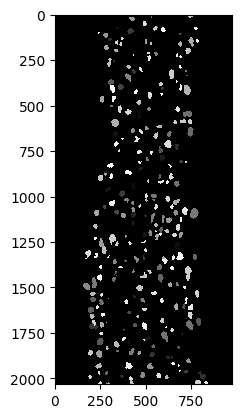

In [4]:
# segmented nuclei mask
stackview.imshow(nuclei_mask[155],axes = True)

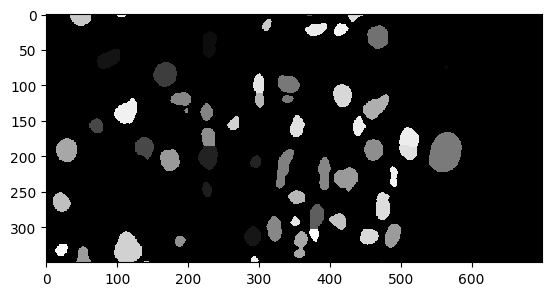

In [6]:
# closer image of nuclei mask
stackview.imshow(nuclei_mask[155, 900:1250,200:900],axes = True)

## 2. Otsus Threshold

In [7]:
threshold_value = threshold_otsu(preprocessed_image[PLANE])
print("extracted threshold value:", threshold_value)

extracted threshold value: 2170.5012


In [8]:
# Create a binary image using the threshold
binary_otsu = preprocessed_image[PLANE] > threshold_value

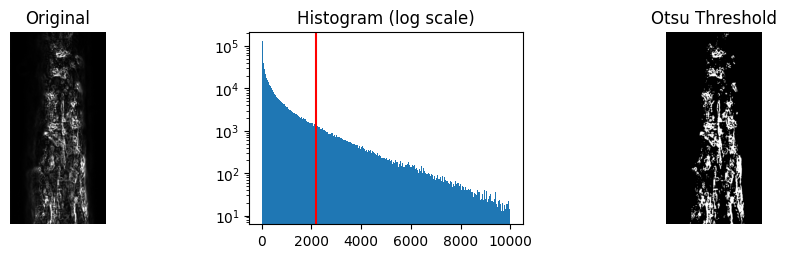

In [9]:
# new histogram with log scale 
fig, axes = plt.subplots(ncols=3, figsize=(12, 2.5))
ax = axes.ravel()
# Display the original image
ax[0].imshow(preprocessed_image[PLANE], cmap=plt.cm.gray, vmax=disp_vmax(preprocessed_image[PLANE]))
ax[0].set_title('Original')
ax[0].axis('off')
# Plot the histogram with the Otsu threshold marked in red
ax[1].hist(preprocessed_image[PLANE].ravel(), bins=1000, range=(10, 10000), log=True)
ax[1].set_title('Histogram (log scale)')
ax[1].axvline(threshold_value, color='r')
# Display the thresholded image
ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title('Otsu Threshold')
ax[2].axis('off')
# Show the subplots
plt.show()

/home/rck292/cardiac_env/lib/python3.11/site-packages/stackview/_imshow.py:54: UserWarning: The parameter cmap is deprecated, use colormap instead.
  warnings.warn("The parameter cmap is deprecated, use colormap instead.")


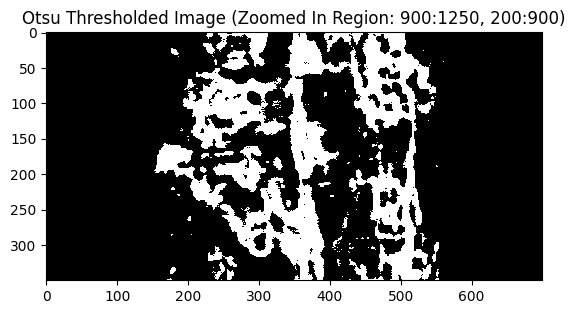

In [10]:
stackview.imshow(binary_otsu[900:1250,200:900], cmap=plt.cm.gray, title='Otsu Thresholded Image (Zoomed In Region: 900:1250, 200:900)', axes=True)

## 3. Multi-Otsu Threshold

In [11]:
# using bimodal histogram from scikit-image to find the threshold value
thresholds = threshold_multiotsu(preprocessed_image[PLANE], classes=3)
print("extracted threshold values:", thresholds)

extracted threshold values: [1302.3009 4254.1826]


In [12]:
binary_multiotsu = preprocessed_image[PLANE] > thresholds[1]

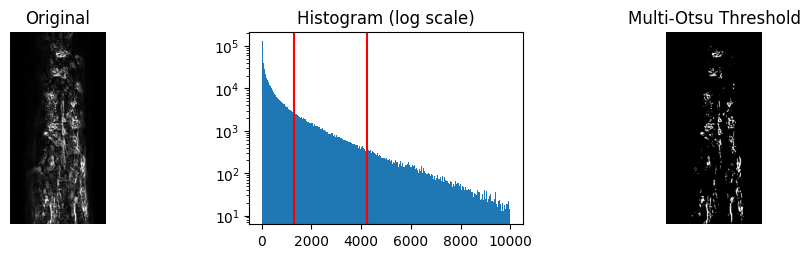

In [13]:
# new histogram with log scale 
fig, axes = plt.subplots(ncols=3, figsize=(12, 2.5))
ax = axes.ravel()
# Display the original image
ax[0].imshow(preprocessed_image[PLANE], cmap=plt.cm.gray, vmax=disp_vmax(preprocessed_image[PLANE]))
ax[0].set_title('Original')
ax[0].axis('off')
# Plot the histogram with the Otsu threshold marked in red
ax[1].hist(preprocessed_image[PLANE].ravel(), bins=1000, range=(10, 10000), log=True)
ax[1].set_title('Histogram (log scale)')
ax[1].axvline(thresholds[0], color='r')
ax[1].axvline(thresholds[1], color='r')
# Display the thresholded image
ax[2].imshow(binary_multiotsu, cmap=plt.cm.gray)
ax[2].set_title('Multi-Otsu Threshold')
ax[2].axis('off')
# Show the subplots
plt.show()

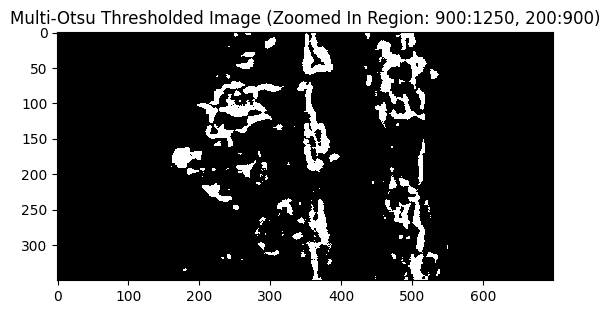

In [14]:
stackview.imshow(binary_multiotsu[900:1250,200:900], cmap=plt.cm.gray, title='Multi-Otsu Thresholded Image (Zoomed In Region: 900:1250, 200:900)', axes=True)

## 4. Sauvola Threshold

Plaques with min distance 2 detected: 8
Plaques with min distance 2 detected: 86
Plaques with min distance 2 detected: 142
Plaques with min distance 2 detected: 221


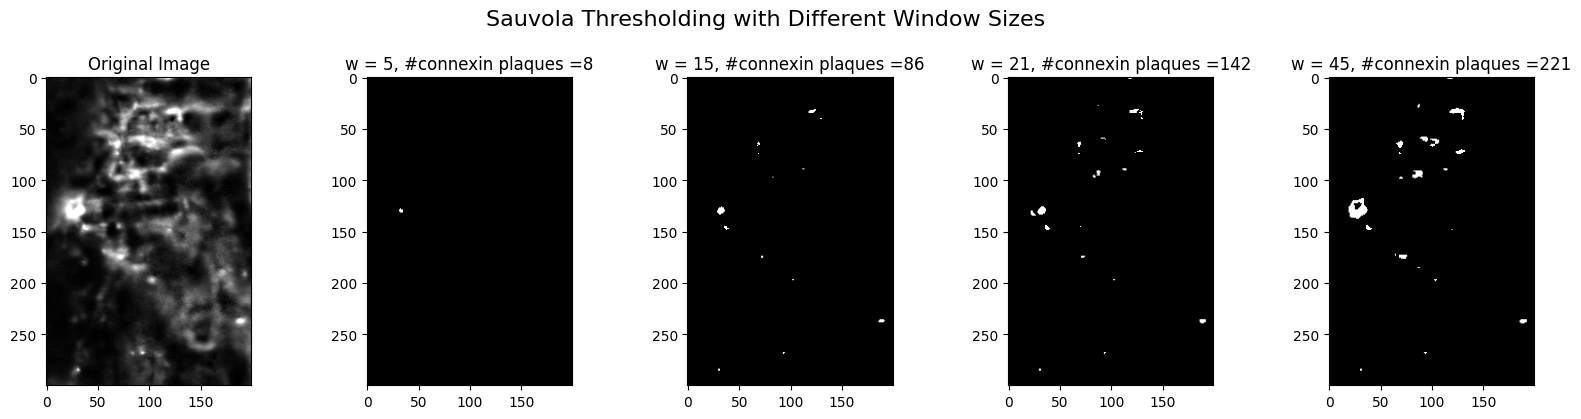

In [15]:
# set some parameters 
min_distance = 2 # connexin size / 2
k_value = 0.15


# Normalize preprocessed image to float [0, 1]
# k the bigger more selective and less foreground [0.2,0.5]
# window size should be 2-3 x diameter of connexin 
# r is 0.5 for image [0,1]
img_float = img_as_float(rescale_intensity(preprocessed_image[PLANE], out_range=(0, 1)))

# Apply adapted Sauvola — no inversion needed
thresh, binary = adapted_sauvola_threshold(img_float, window_size=31, k = k_value , r=0.5)

# stackview.imshow(binary)

thresh, binary_5 = adapted_sauvola_threshold(img_float, window_size=5, k = k_value , r=0.5)
thresh, binary_15 = adapted_sauvola_threshold(img_float, window_size=15, k = k_value , r=0.5)
thresh, binary_21 = adapted_sauvola_threshold(img_float, window_size=21, k = k_value , r=0.5)
thresh, binary_45 = adapted_sauvola_threshold(img_float, window_size=45, k = k_value , r=0.5)

# compute the number of plaques for each binary image 
num_regions_5, labeled_array_5 = count_connexin_plaques(binary_5)
num_regions_15, labeled_array_15 = count_connexin_plaques(binary_15)
num_regions_21, labeled_array_21 = count_connexin_plaques(binary_21)
num_regions_45, labeled_array_45 = count_connexin_plaques(binary_45)

# compute the number of plaques for each binary image -> this counts 2 peaks that are closer than min_distance as one plaque
coordinates_5, n_plaques_5 = count_connexin_plaques_within_plaque(img_float, binary_5, min_distance=min_distance)
coordinates_15, n_plaques_15 = count_connexin_plaques_within_plaque(img_float, binary_15, min_distance=min_distance)
coordinates_25, n_plaques_25 = count_connexin_plaques_within_plaque(img_float, binary_21, min_distance=min_distance)
coordinates_45, n_plaques_45 = count_connexin_plaques_within_plaque(img_float, binary_45, min_distance=min_distance)

#make a subplot with different window sizes 
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# set a title for the entire figure with a distance from the top of the figure
fig.suptitle('Sauvola Thresholding with Different Window Sizes', fontsize=16, y=1.05)
axes[0].imshow(img_float[950:1250, 350:550], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:550]))
axes[0].set_title('Original Image')
axes[1].imshow(binary_5[950:1250, 350:550], cmap='gray')
axes[1].set_title(f'w = 5, #connexin plaques ={len(coordinates_5)}')
axes[2].imshow(binary_15[950:1250, 350:550], cmap='gray')
axes[2].set_title(f'w = 15, #connexin plaques ={len(coordinates_15)}')
axes[3].imshow(binary_21[950:1250, 350:550], cmap='gray')
axes[3].set_title(f'w = 21, #connexin plaques ={len(coordinates_25)}')
axes[4].imshow(binary_45[950:1250, 350:550], cmap='gray')
axes[4].set_title(f'w = 45, #connexin plaques ={len(coordinates_45)}')
plt.show()

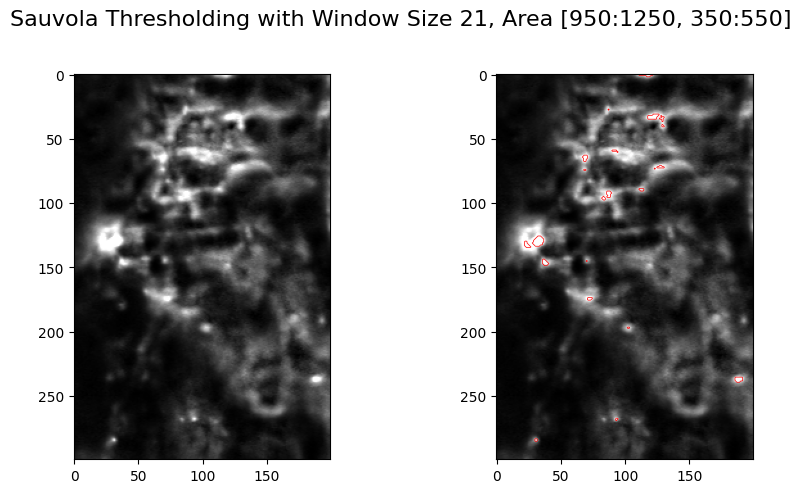

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(10, 5))
fig.suptitle('Sauvola Thresholding with Window Size 21, Area [950:1250, 350:550]', fontsize=16, y=1.01)
ax[0].imshow(img_float[950:1250, 350:550], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:550]))
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[1].imshow(img_float[950:1250, 350:550], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:550]))
ax[1].contour( binary_21[950:1250, 350:550], [0.5], linewidths=0.5, colors='r')
plt.show()

## 4. Compare Methods

In [ ]:
mask_areas = io.imread(BASE_DIR / 'data/manual_annotations/small_deconvolved_3d_plane_160_labels.tif')
# match the left cut (3) applied in preprocessing so the annotation stays aligned
mask_areas = mask_areas[:, 3:]

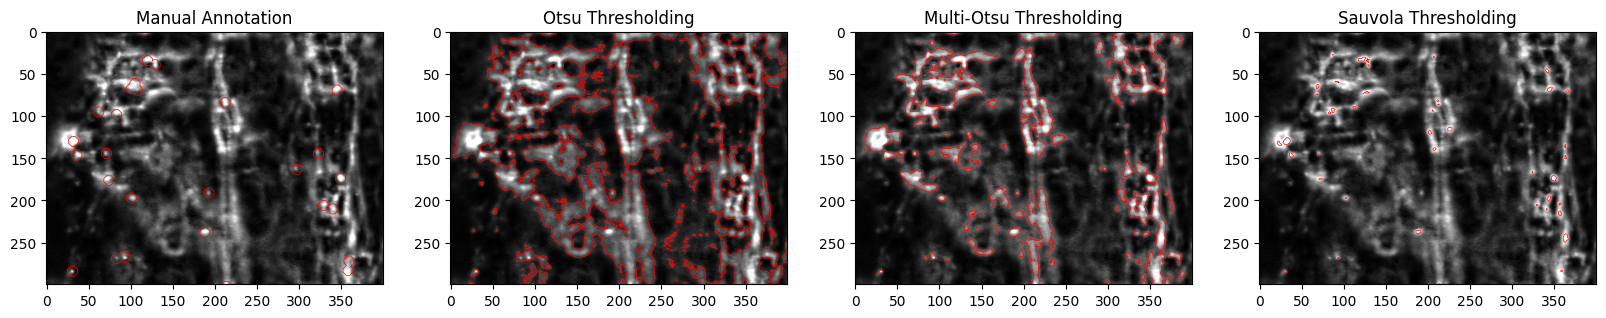

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,4, figsize=(20, 5))
# ax[0].imshow(img_float[950:1250, 350:550], cmap='gray')
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[0].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[0].contour(mask_areas[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[0].set_title('Manual Annotation')
ax[1].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[1].contour(binary_otsu[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[1].set_title('Otsu Thresholding')
ax[2].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[2].contour( binary_multiotsu[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[2].set_title('Multi-Otsu Thresholding')
ax[3].imshow(img_float[950:1250, 350:750], cmap='gray', vmax=disp_vmax(img_float[950:1250, 350:750]))
ax[3].contour( binary_21[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[3].set_title('Sauvola Thresholding')
plt.show()

## 5. Apply Sauvola on 3D image

In [40]:
# Derive the normalization bounds automatically from the image so the pipeline generalizes to
# other acquisitions instead of using fixed constants (see estimate_normalization_bounds):
#   v_low  = robust background floor  (median + 3 * 1.4826 * MAD)
#   v_high = 95th percentile of the coarse-Otsu foreground (lands on real plaque signal, not the
#            sparse-signal-dominated background). Previously hand-tuned to ~1000 / ~25000.
v_low, v_high = estimate_normalization_bounds(preprocessed_image, low_sigma=1.4, high_percentile=99.95)
print(f"v_low = {v_low:.1f}")
print(f"v_high = {v_high:.1f}")

v_low = 961.1
v_high = 24735.9


In [51]:
preprocessed_image.max()

np.float32(142627.69)

In [41]:
# apply adapted Sauvola to the entire stack (global normalization + local mean/std)
# window is (z, y, x); z ~ 9 keeps the 3D window ~isotropic (voxels 0.766 um z vs 0.325 xy: 21*0.325/0.766 ~ 9)
threeD = True
binary_sauvola_raw = savola_3D_image(preprocessed_image, v_low=v_low, v_high=v_high, window_size=(9, 21, 21), k=0.15, r=0.5, threeD=threeD)

In [42]:
# save sauvola image with labelled regions 
# save the binary_sauvola_raw for later use
io.imsave(
    BASE_DIR / 'data/segmented/binary_sauvola3d_w9_21_21_k0_15.tiff',
    img_as_ubyte(binary_sauvola_raw)
)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/segmented/binary_sauvola3d_w9_21_21_k0_15.tiff is a low contrast image
  return func(*args, **kwargs)


### Label connected connexin regions (3D)

In [52]:
# 3D-label the segmented mask into plaques (the labelling done in 3_localization): groups connected
# foreground voxels across planes into single objects, so counts/sizes are per-plaque not per-slice.
labeled_3d, n_components = label_connexin_regions_3d(binary_sauvola_raw, connectivity=1)

Labeling connected regions in 3D...
  Connected regions found: 20985


In [53]:
labeled_3d.max()

np.int32(20985)

In [54]:
# save sauvola image with labelled regions 
# save the binary_sauvola_raw for later use
io.imsave(
    BASE_DIR / 'data/segmented/labelled_sauvola3d_w9_21_21_k0_15.tiff',
    labeled_3d
)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/segmented/labelled_sauvola3d_w9_21_21_k0_15.tiff is a low contrast image
  return func(*args, **kwargs)


### Example planes: Sauvola settings on plane 160 (for the 2_2 validation)

Segment the manually-annotated plane 160 with several `(window, k)` settings and save each as a 2D mask, so `2_2_validation` can read them back and compare against the manual annotation.

In [45]:
# plane 160 is the manually annotated plane; this stack is cropped [60:501], so its index is 160-60 = 100
ANNOT_PLANE = 160 - 60

# normalize with the SAME global bounds used for the full-stack segmentation (absolute in_range,
# so normalizing just this plane is identical to normalizing the whole stack and indexing it)
plane_norm = normalize_img(preprocessed_image[ANNOT_PLANE], v_low, v_high)

# (window, k) settings to compare
sauvola_settings = [(21, 0.2), (15, 0.1), (21, 0.15), (21, 0.1)]

for w, k in sauvola_settings:
    _, binary_plane = adapted_sauvola_threshold(plane_norm, window_size=w, k=k, r=0.5)
    fname = f"plane160_sauvola_w{w}_k{str(k).replace('.', '_')}.tiff"
    io.imsave(BASE_DIR / 'data/segmented' / fname, img_as_ubyte(binary_plane))
    print("saved", fname)

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/segmented/plane160_sauvola_w21_k0_2.tiff is a low contrast image
  return func(*args, **kwargs)


saved plane160_sauvola_w21_k0_2.tiff
saved plane160_sauvola_w15_k0_1.tiff
saved plane160_sauvola_w21_k0_15.tiff
saved plane160_sauvola_w21_k0_1.tiff


/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/segmented/plane160_sauvola_w21_k0_15.tiff is a low contrast image
  return func(*args, **kwargs)


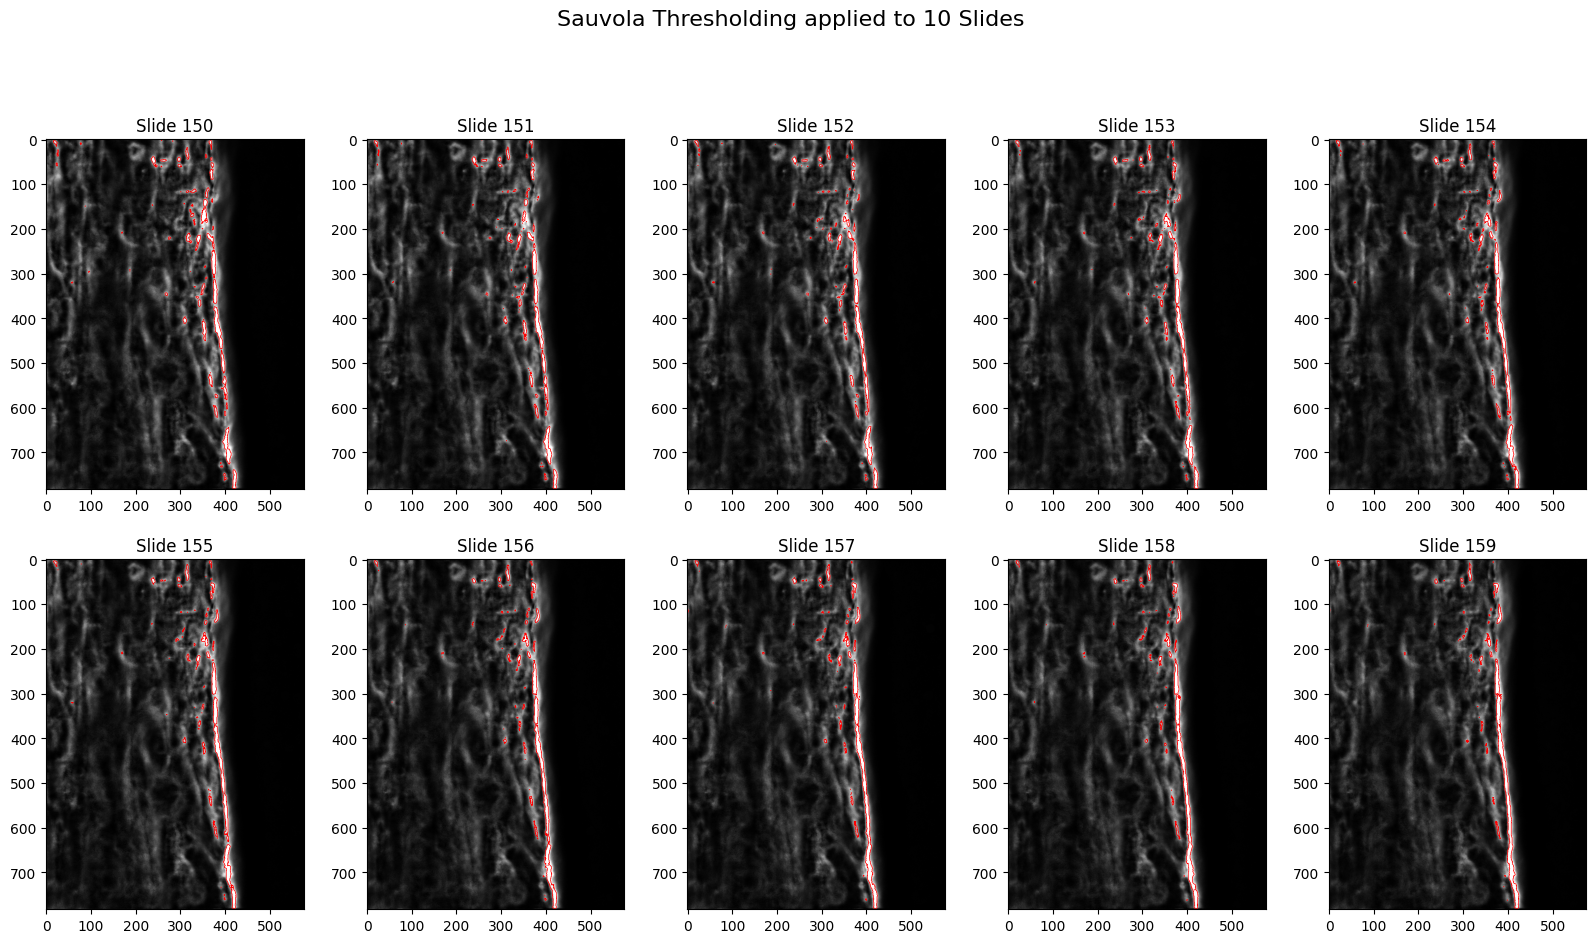

In [46]:
# plot 10 slides with segmented connexin next to each other [950:1250, 350:550]
fig, ax = plt.subplots(2, 5, figsize=(20, 10))
plane = 150
fig.suptitle('Sauvola Thresholding applied to 10 Slides', fontsize=16, y=1.01)
for i in range(10):
    ax[i//5, i%5].imshow(preprocessed_image[plane+i][1250:, 400:], cmap='gray', vmax=disp_vmax(preprocessed_image[100+i][1250:, 400:]))
    ax[i//5, i%5].contour(binary_sauvola_raw[plane+i][1250:, 400:], [0.5], linewidths=0.5, colors='r')
    ax[i//5, i%5].set_title(f'Slide {plane+i}')

plt.show()

### Plaque size distribution

Size (voxels and µm³) of every labelled 3D connexin plaque (from labeled_3d), with the min / mean / max.

Segmented plaques (3D components): 20985
  min  size : 1 voxels (0.081 um^3)
  mean size : 136.6 voxels (11.049 um^3)
  max  size : 599668 voxels (48518.388 um^3)


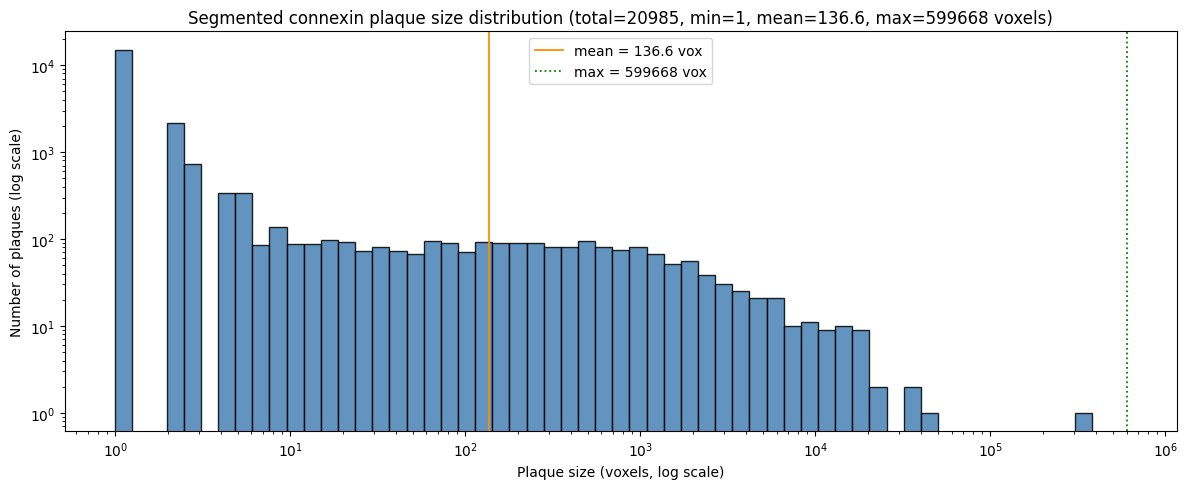

In [47]:
import numpy as np
import matplotlib.pyplot as plt

VOXEL_VOLUME_UM3 = 0.766 * 0.325 * 0.325   # z*y*x spacing, matches 3_localization

# plaque sizes = voxels per labelled 3D connected region
sizes = np.bincount(labeled_3d.ravel())[1:]   # drop background (label 0)

total = sizes.size
size_min, size_mean, size_max = int(sizes.min()), float(sizes.mean()), int(sizes.max())

print(f"Segmented plaques (3D components): {total}")
print(f"  min  size : {size_min} voxels ({size_min * VOXEL_VOLUME_UM3:.3f} um^3)")
print(f"  mean size : {size_mean:.1f} voxels ({size_mean * VOXEL_VOLUME_UM3:.3f} um^3)")
print(f"  max  size : {size_max} voxels ({size_max * VOXEL_VOLUME_UM3:.3f} um^3)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sizes, bins=np.logspace(0, np.log10(size_max), 60),
        color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xscale('log'); ax.set_yscale('log')
ax.axvline(size_mean, color='darkorange', ls='-', lw=1.3, label=f'mean = {size_mean:.1f} vox')
ax.axvline(size_max, color='green', ls=':', lw=1.3, label=f'max = {size_max} vox')
ax.set_xlabel('Plaque size (voxels, log scale)')
ax.set_ylabel('Number of plaques (log scale)')
ax.set_title(f'Segmented connexin plaque size distribution '
             f'(total={total}, min={size_min}, mean={size_mean:.1f}, max={size_max} voxels)')
ax.legend()
plt.tight_layout()
plt.show()

### Single-voxel plaques per plane

How many size-1 (single-voxel) plaques — isolated foreground voxels, i.e. threshold noise — sit on each z-plane.

Single-voxel plaques: 15095 of 20985 plaques (71.9%)


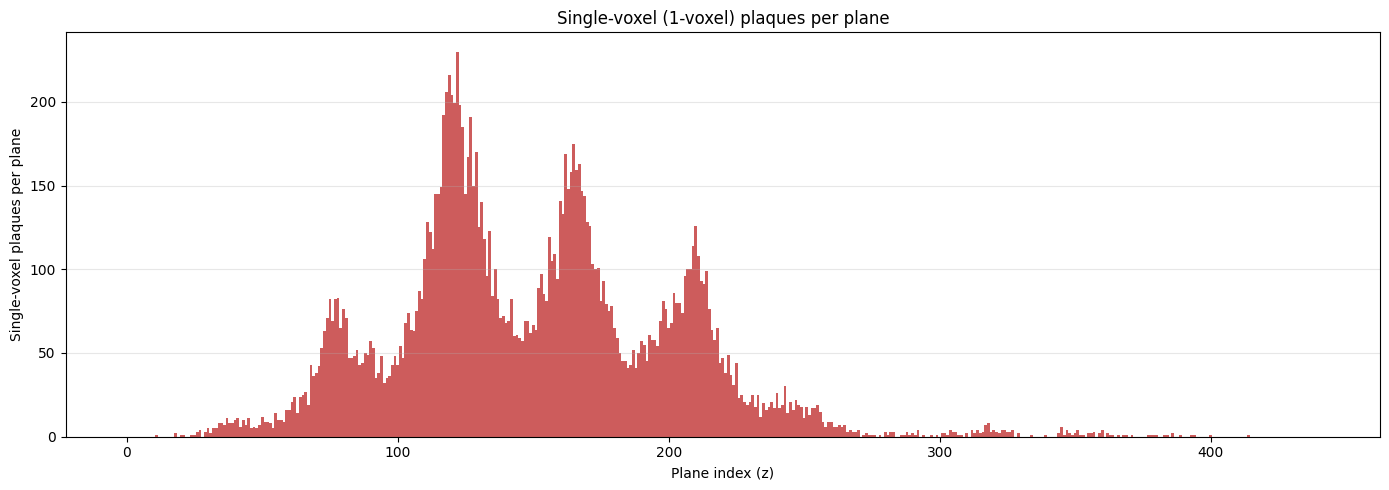

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# single-voxel plaques = 3D labelled regions of size 1 (isolated voxels; each sits on one plane)
sizes_full = np.bincount(labeled_3d.ravel())     # index 0 = background (large, so never size 1)
is_single = sizes_full == 1                        # True for size-1 labels
single_mask = is_single[labeled_3d]                # True at every single-voxel plaque
single_per_plane = single_mask.reshape(single_mask.shape[0], -1).sum(axis=1)

n_planes = labeled_3d.shape[0]
n_plaques = int((sizes_full[1:] > 0).sum())
print(f"Single-voxel plaques: {int(single_per_plane.sum())} of {n_plaques} plaques ({single_per_plane.sum()/max(n_plaques,1):.1%})")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(n_planes), single_per_plane, width=1.0, color='indianred', edgecolor='none')
ax.set_xlabel('Plane index (z)')
ax.set_ylabel('Single-voxel plaques per plane')
ax.set_title('Single-voxel (1-voxel) plaques per plane')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()